<a href="https://colab.research.google.com/github/haru452/anime_super-resolution/blob/main/hexgon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

読み込んだ画像:
  Frame 0: shape=(128, 128)
  Frame 1: shape=(128, 128)
  Frame 2: shape=(128, 128)

回転補正を適用中...
クロップ後のサイズ: (98, 98)

サブピクセル位置合わせを実行中...
  Frame 0: dx = +0.0000, dy = +0.0000 (基準)
  Frame 1: dx = +0.2443, dy = +0.5267 (信頼度: 0.7941)
  Frame 2: dx = -0.3104, dy = +0.2156 (信頼度: 0.9595)

散布点の総数: 28812 点 (9604 画素 x 3 枚)
生成した六角格子点数: 19781 点 (spacing=0.75)

六角格子をラスタ画像化中...


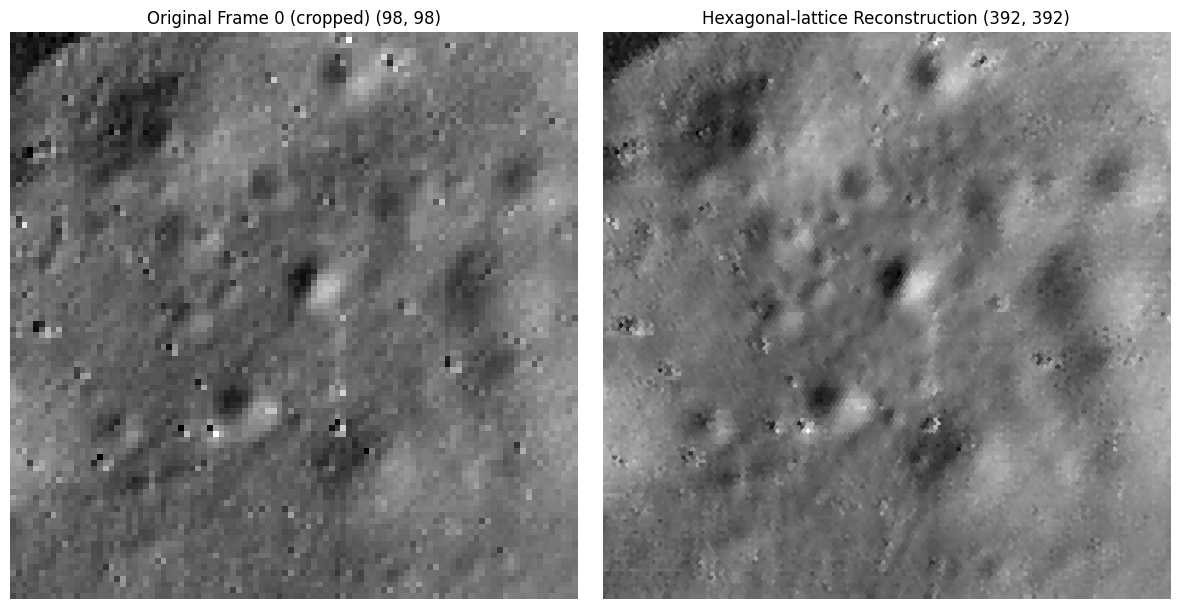

結果を 'hex_reconstruction.png' に保存しました。


In [8]:
import glob
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.spatial import cKDTree

# ======================================================
# 0. 画像の読み込み
# ======================================================
paths = sorted(glob.glob("bs*.png"))  # bs1.png ~ bs4.png
images = [cv2.imread(p, cv2.IMREAD_GRAYSCALE).astype(np.float32) for p in paths]
for i,img in enumerate( images):
  new_size = (img.shape[1] // 2, img.shape[0] // 2)
  images[i] = cv2.resize(img, new_size, interpolation=cv2.INTER_CUBIC)

if not images or any(img is None for img in images):
    raise FileNotFoundError("画像が見つかりません。paths のパスを確認してください。")

print("読み込んだ画像:")
for i, img in enumerate(images):
    print(f"  Frame {i}: shape={img.shape}")


# ======================================================
# 1. 回転補正(Frame 0 の向きに全フレームを合わせる)
# ======================================================
def align_rotation(base, img):
    orb = cv2.ORB_create(1000)
    kp1, des1 = orb.detectAndCompute(base.astype(np.uint8), None)
    kp2, des2 = orb.detectAndCompute(img.astype(np.uint8), None)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = sorted(bf.match(des1, des2), key=lambda m: m.distance)[:50]
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])
    M, _ = cv2.estimateAffinePartial2D(pts2, pts1)
    h, w = base.shape
    aligned = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LANCZOS4,
                              borderMode=cv2.BORDER_REPLICATE)
    return aligned


print("\n回転補正を適用中...")
aligned_images = [images[0]] + [align_rotation(images[0], img) for img in images[1:]]


# ======================================================
# 2. 有効領域のクロップ(縁のアーティファクトを除去)
# ======================================================
def crop_valid_region(imgs, margin_ratio=0.12):
    h, w = imgs[0].shape
    my, mx = int(h * margin_ratio), int(w * margin_ratio)
    return [img[my:h - my, mx:w - mx] for img in imgs]


aligned_images = crop_valid_region(aligned_images, margin_ratio=0.12)
h, w = aligned_images[0].shape
print(f"クロップ後のサイズ: {aligned_images[0].shape}")


# ======================================================
# 3. サブピクセルオフセット推定
# ======================================================
# ======================================================
# 3. サブピクセルオフセット推定 (バグを修正した完全版)
# ======================================================
def estimate_offsets(frames):
    offsets = []
    base_frame = frames[0].astype(np.float32)

    # 画像サイズ
    hh, ww = base_frame.shape
    # 中央の 60% のエリア（ROI）を切り出して位置合わせの精度を上げる
    cy, cx = hh // 2, ww // 2
    dy_roi, dx_roi = int(hh * 0.3), int(ww * 0.3)

    base_roi = base_frame[cy-dy_roi : cy+dy_roi, cx-dx_roi : cx+dx_roi]
    # ハニング窓の作成（位相相関の端のノイズを軽減するため）
    win = cv2.createHanningWindow((base_roi.shape[1], base_roi.shape[0]), cv2.CV_32F)

    print("\nサブピクセル位置合わせを実行中...")
    for i, frame in enumerate(frames):
        if i == 0:
            offsets.append((0.0, 0.0))
            print(f"  Frame {i}: dx = +0.0000, dy = +0.0000 (基準)")
            continue

        # ターゲットフレームの中央領域
        frame_roi = frame.astype(np.float32)[cy-dy_roi : cy+dy_roi, cx-dx_roi : cx+dx_roi]

        try:
            # 位相相関法によるサブピクセル精度のシフト推定
            shift, response = cv2.phaseCorrelate(base_roi, frame_roi, win)
            dx, dy = shift

            # 推定されたズレを記録
            offsets.append((dx, dy))
            print(f"  Frame {i}: dx = {dx:+.4f}, dy = {dy:+.4f} (信頼度: {response:.4f})")

        except Exception as e:
            print(f"  Frame {i}: 位置合わせ失敗。エラー: {e}")
            offsets.append((0.0, 0.0))

    return offsets

# オフセットの計算を実行
estimated_offsets = estimate_offsets(aligned_images)


# ======================================================
# 4. 全フレームの画素を「散布点群」として基準座標系にまとめる
# ======================================================
def build_point_cloud(images, offsets):
    """
    フレームnの座標(j, i)の画素は、基準フレーム座標系では (j - dx_n, i - dy_n) の
    位置にある観測値とみなせる(位相相関のシフト理論に基づく)。
    これを全フレーム分集めて、1つの散布点群 (x, y, value) にする。
    """
    base_mean = np.mean(images[0])
    hh, ww = images[0].shape
    jj, ii = np.meshgrid(np.arange(ww), np.arange(hh))  # jj=x(col), ii=y(row)

    xs, ys, vs = [], [], []
    for img, (dx, dy) in zip(images, offsets):
        norm = img * (base_mean / (np.mean(img) + 1e-8))  # 明るさの正規化
        xs.append((jj - dx).ravel())
        ys.append((ii - dy).ravel())
        vs.append(norm.ravel())

    return np.concatenate(xs), np.concatenate(ys), np.concatenate(vs)


pts_x, pts_y, vals = build_point_cloud(aligned_images, estimated_offsets)
print(f"\n散布点の総数: {len(vals)} 点"
      f" ({aligned_images[0].size} 画素 x {len(aligned_images)} 枚)")


# ======================================================
# 5. 六角格子(ハニカム格子)の生成
# ======================================================
def generate_hex_grid(h, w, spacing):
    """
    spacing: 同じ行内の隣接する六角格子点どうしの距離(元画像のピクセル単位)。
    spacing を1より小さくすると、元の1ピクセル間隔より密なサンプリング
    (=解像度向上)になる。
    """
    row_spacing = spacing * math.sqrt(3) / 2.0
    points = []
    row = 0
    y = 0.0
    while y < h:
        x_offset = (spacing / 2.0) if (row % 2 == 1) else 0.0
        x = x_offset
        while x < w:
            points.append((x, y))
            x += spacing
        y += row_spacing
        row += 1
    return np.array(points)


# フレーム間の位相の多様性が乏しいため(前回の検証結果より)、控えめな値にしている。
# 位相の分布が良い場合は 0.5〜0.6 程度まで攻めても良い。
HEX_SPACING = 0.75
hex_points = generate_hex_grid(h, w, HEX_SPACING)
print(f"生成した六角格子点数: {len(hex_points)} 点 (spacing={HEX_SPACING})")


# ======================================================
# 6. 散布データを六角格子点へ補間
# ======================================================
hex_values = griddata((pts_x, pts_y), vals, hex_points, method='linear')

# 三角形分割の範囲外(NaN)は最近傍で埋める
nan_mask = np.isnan(hex_values)
if nan_mask.any():
    hex_values_nn = griddata((pts_x, pts_y), vals, hex_points, method='nearest')
    hex_values[nan_mask] = hex_values_nn[nan_mask]


# ======================================================
# 7. 六角格子をラスタ画像として描画
#    (三角格子のボロノイ図=正六角形になる性質を利用して、
#     最近傍の格子点を割り当てるだけで六角形タイル状の画像が作れる)
# ======================================================
def rasterize_hex(hex_points, hex_values, h, w, upscale=4):
    out_h, out_w = h * upscale, w * upscale
    yy, xx = np.meshgrid(np.arange(out_h) / upscale, np.arange(out_w) / upscale, indexing='ij')
    query_pts = np.stack([xx.ravel(), yy.ravel()], axis=-1)

    tree = cKDTree(hex_points)
    _, idx = tree.query(query_pts, k=1)

    return hex_values[idx].reshape(out_h, out_w)


print("\n六角格子をラスタ画像化中...")
raster_img = rasterize_hex(hex_points, hex_values, h, w, upscale=4)

raster_norm = cv2.normalize(raster_img, None, 0, 255, cv2.NORM_MINMAX)
raster_u8 = raster_norm.astype(np.uint8)


# ======================================================
# 8. 結果の表示と保存
# ======================================================
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f"Original Frame 0 (cropped) {aligned_images[0].shape}")
plt.imshow(aligned_images[0], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Hexagonal-lattice Reconstruction {raster_u8.shape}")
plt.imshow(raster_u8, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.savefig("hex_comparison.png", dpi=150)
plt.show()

cv2.imwrite("hex_reconstruction.png", raster_u8)
print("結果を 'hex_reconstruction.png' に保存しました。")

In [9]:
# ======================================================
# 5-2. 四角形格子（正方形格子）の生成
# ======================================================
def generate_square_grid(h, w, spacing):
    """
    spacing: 隣接する格子点どうしの距離。
    六角格子(0.75)と同じスケールで比較するために同じ値に設定します。
    """
    # 四角形（正方形）なので、縦も横も同じ等間隔（spacing）でループを回します
    points = []

    y = 0.0
    while y < h:
        x = 0.0
        while x < w:
            points.append((x, y))
            x += spacing
        y += spacing

    return np.array(points)

# 六角格子と同じ spacing で生成
SQUARE_SPACING = 0.75
square_points = generate_square_grid(h, w, SQUARE_SPACING)
print(f"生成した四角形格子点数: {len(square_points)} 点 (spacing={SQUARE_SPACING})")


# ======================================================
# 6-2. 散布データを四角形格子点へ補間
# ======================================================
square_values = griddata((pts_x, pts_y), vals, square_points, method='linear')

# 外挿（NaN）処理も同様に
nan_mask_sq = np.isnan(square_values)
if nan_mask_sq.any():
    square_values_nn = griddata((pts_x, pts_y), vals, square_points, method='nearest')
    square_values[nan_mask_sq] = square_values_nn[nan_mask_sq]


# ======================================================
# 7-2. 四角形格子をラスタ画像として描画（KDTreeで一番近い点を割り当てる）
# ======================================================
def rasterize_square(square_points, square_values, h, w, upscale=4):
    out_h, out_w = h * upscale, w * upscale
    yy, xx = np.meshgrid(np.arange(out_h) / upscale, np.arange(out_w) / upscale, indexing='ij')
    query_pts = np.stack([xx.ravel(), yy.ravel()], axis=-1)

    tree = cKDTree(square_points)
    _, idx = tree.query(query_pts, k=1)
    return square_values[idx].reshape(out_h, out_w)

print("\n四角形格子をラスタ画像化中...")
raster_img_sq = rasterize_square(square_points, square_values, h, w, upscale=4)
raster_norm_sq = cv2.normalize(raster_img_sq, None, 0, 255, cv2.NORM_MINMAX)
raster_u8_sq = raster_norm_sq.astype(np.uint8)

# 保存
cv2.imwrite("square_reconstruction.png", raster_u8_sq)
print("結果を 'square_reconstruction.png' に保存しました。")

生成した四角形格子点数: 17161 点 (spacing=0.75)

四角形格子をラスタ画像化中...
結果を 'square_reconstruction.png' に保存しました。


## Edge detection


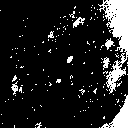

In [17]:

# 1. 読み込んだ画像を 0~255 の uint8 に変換する
img_uint8 = cv2.normalize(images[0], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 2. その後、閾値 150 で二値化する
T = 150
ret, img_b_thresh = cv2.threshold(img_uint8, T, 255, cv2.THRESH_BINARY)
cv2_imshow(img_b_thresh)

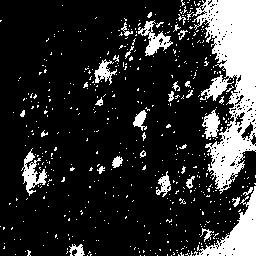

In [16]:
img = cv2.imread('bs1.png')
# 1. 読み込んだ画像を 0~255 の uint8 に変換する
img_uint8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 2. その後、閾値 150 で二値化する
T = 150
ret, img_b_thresh = cv2.threshold(img_uint8, T, 255, cv2.THRESH_BINARY)
cv2_imshow(img_b_thresh)

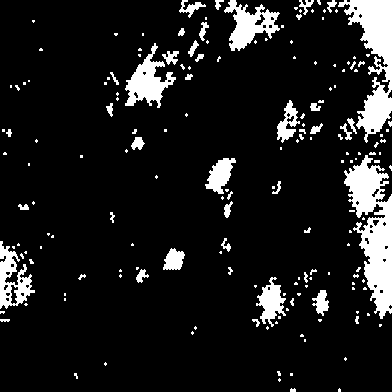

True

In [18]:
#e = 0.03
#T0 = basicGlobalThreshold(img, e)
#print(T0)
T = 150
ret, img_b_thresh = cv2.threshold(raster_u8,T,255,cv2.THRESH_BINARY)
cv2_imshow(img_b_thresh)
cv2.imwrite("a.png",img_b_thresh)



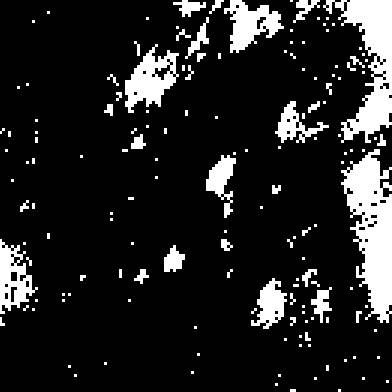

True

In [19]:
#e = 0.03
#T0 = basicGlobalThreshold(img, e)
#print(T0)
T = 150
ret, img_b_thresh = cv2.threshold(raster_u8_sq,T,255,cv2.THRESH_BINARY)
cv2_imshow(img_b_thresh)
cv2.imwrite("a.png",img_b_thresh)



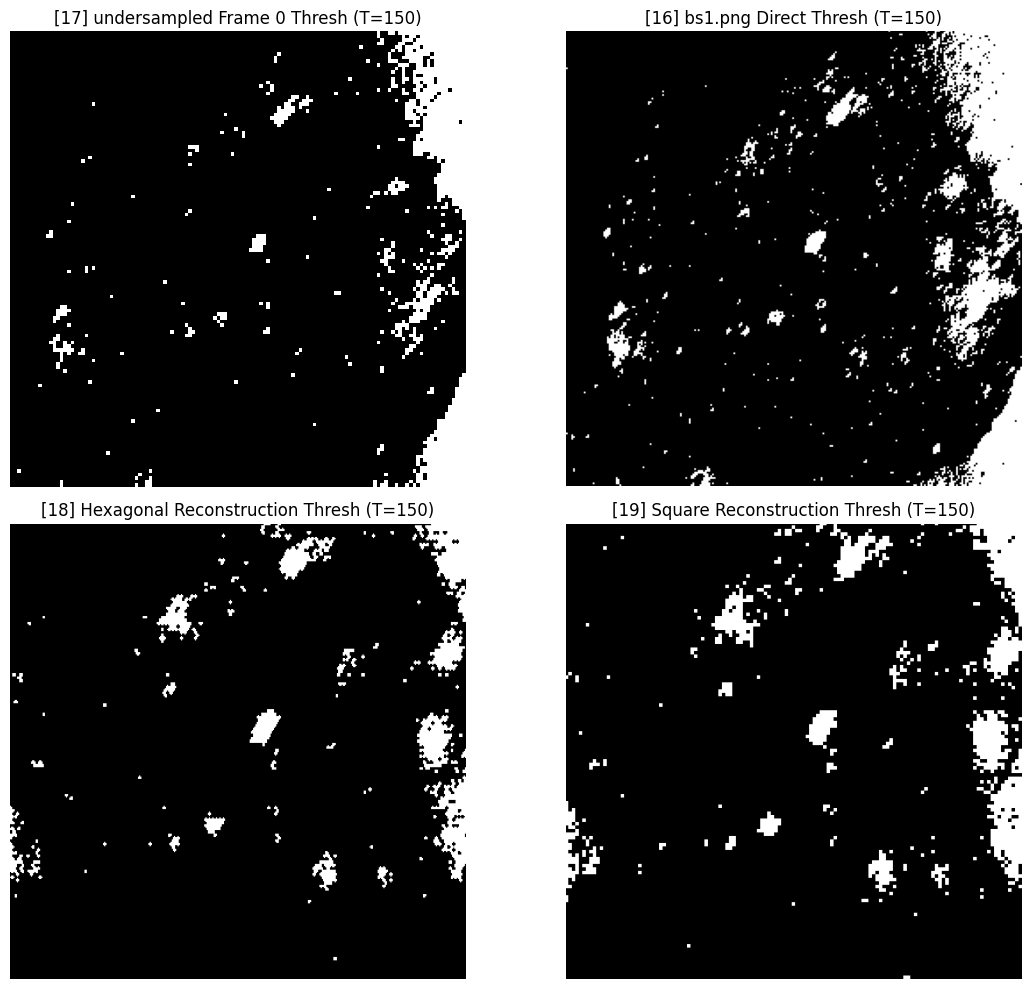

比較画像を 'threshold_comparison_2x2.png' として保存しました。


In [22]:
# ======================================================
# [17]〜[19] の二値化結果を 2x2 で並べて比較表示
# ======================================================

# 1. 各セルの二値化処理を個別に再現（変数名が上書きされないように個別の変数に格納します）
T = 160

# [17] 原画像 (images[0]) の二値化
img_uint8_17 = cv2.normalize(images[0], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
_, thresh_17 = cv2.threshold(img_uint8_17, T, 255, cv2.THRESH_BINARY)

# [16] 直接読み込んだ 'bs1.png' の二値化
img_16 = cv2.imread('bs1.png')
img_uint8_16 = cv2.normalize(img_16, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
_, thresh_16 = cv2.threshold(img_uint8_16, T, 255, cv2.THRESH_BINARY)

# [18] 六角格子再構成 (raster_u8) の二値化
_, thresh_18 = cv2.threshold(raster_u8, T, 255, cv2.THRESH_BINARY)

# [19] 四角格子再構成 (raster_u8_sq) の二値化
_, thresh_19 = cv2.threshold(raster_u8_sq, T, 255, cv2.THRESH_BINARY)


# 2. matplotlib を使って 2x2 のグリッドに描画
plt.figure(figsize=(12, 10))

# 左上: [17]
plt.subplot(2, 2, 1)
plt.title("[17] undersampled Frame 0 Thresh (T=150)")
plt.imshow(thresh_17, cmap='gray')
plt.axis('off')

# 右上: [16]
plt.subplot(2, 2, 2)
plt.title("[16] bs1.png Direct Thresh (T=150)")
plt.imshow(thresh_16, cmap='gray')
plt.axis('off')

# 左下: [18]
plt.subplot(2, 2, 3)
plt.title("[18] Hexagonal Reconstruction Thresh (T=150)")
plt.imshow(thresh_18, cmap='gray')
plt.axis('off')

# 右下: [19]
plt.subplot(2, 2, 4)
plt.title("[19] Square Reconstruction Thresh (T=150)")
plt.imshow(thresh_19, cmap='gray')
plt.axis('off')

plt.tight_layout()

# 3. 比較画像を保存して表示
plt.savefig("threshold_comparison_2x2.png", dpi=150)
plt.show()

print("比較画像を 'threshold_comparison_2x2.png' として保存しました。")